# Iris, MNIST, and Synthetic Blobs: Decision Tree Classification

## Project Overview

This notebook evaluates decision-tree classification across three different settings: a small structured tabular dataset, a two-feature synthetic pass/fail problem, and the high-dimensional MNIST image dataset.

The MNIST section also studies model complexity and overfitting through maximum-depth and maximum-leaf constraints.

### Technical Coverage

- Entropy-based decision-tree classification
- Tree visualization
- Multiclass confusion matrices
- Synthetic two-feature classification
- Entropy vs. Gini impurity
- Best vs. random splitters
- Maximum-depth sensitivity
- Maximum-leaf sensitivity
- Training/test accuracy and overfitting

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


## 2. Iris Dataset

The Iris dataset provides four continuous features and three target classes. A fixed train/test split is used for reproducible evaluation.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

dataset = load_iris()
x = dataset.data
y = dataset.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

### Entropy-Based Classifier

In [3]:
model = DecisionTreeClassifier(criterion='entropy')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
cm = confusion_matrix(y_test, pred)
print(cm)

Accuracy 0.9667
[[ 7  0  0]
 [ 0 14  0]
 [ 0  1  8]]


### Tree Visualization without Feature Labels

The first visualization shows the fitted tree using the default node information.

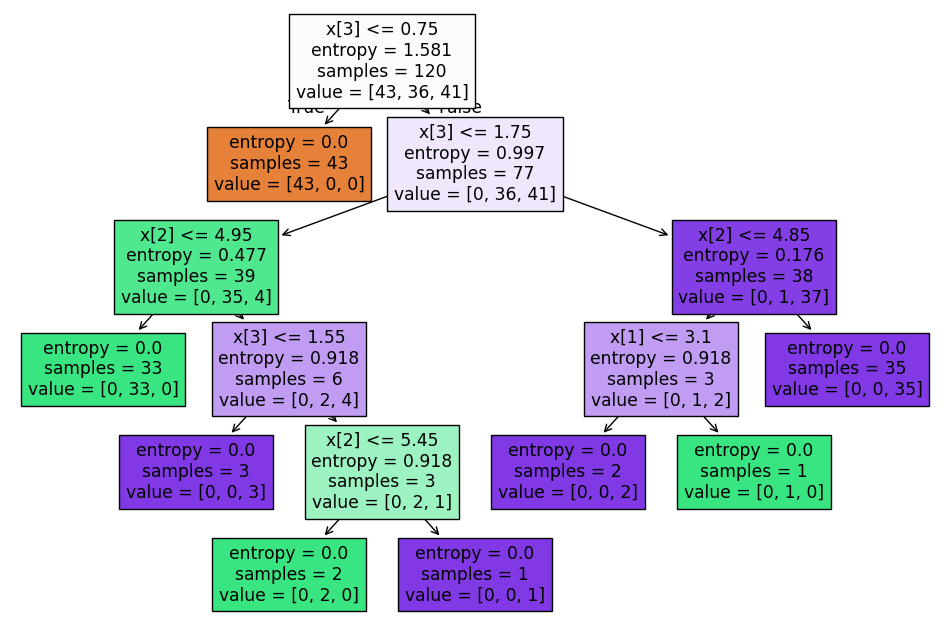

In [4]:
fig, ax = plt.subplots(figsize=(12,8))
t = tree.plot_tree(model, label='all',filled=True)

### Tree Visualization with Feature and Class Names

The second visualization adds the original feature names and class names to improve interpretability.

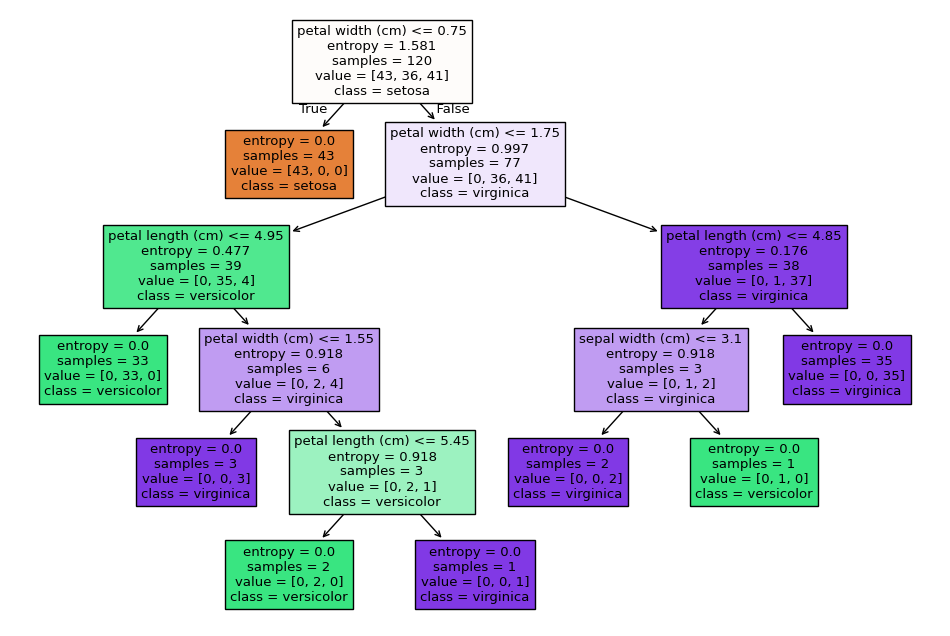

In [5]:
fig, ax = plt.subplots(figsize=(12,8))
t = tree.plot_tree(model, feature_names=dataset.feature_names,class_names=dataset.target_names,label='all',filled=True)

### Iris Result

The saved test accuracy is **0.9667**, with only one test observation misclassified in the saved confusion matrix.

## 3. Synthetic Pass/Fail Classification

A two-feature synthetic dataset represents exam scores and a binary pass/fail target. The learned tree can be interpreted directly in the original two-dimensional feature space.

In [6]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples = [20,40,40,100],random_state=2, centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])
y = np.int16(y==3)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

model = DecisionTreeClassifier(criterion='entropy')
model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
cm = confusion_matrix(y_test, pred)
print(cm)

Accuracy 0.89
[[46  6]
 [ 5 43]]


### Learned Pass/Fail Tree

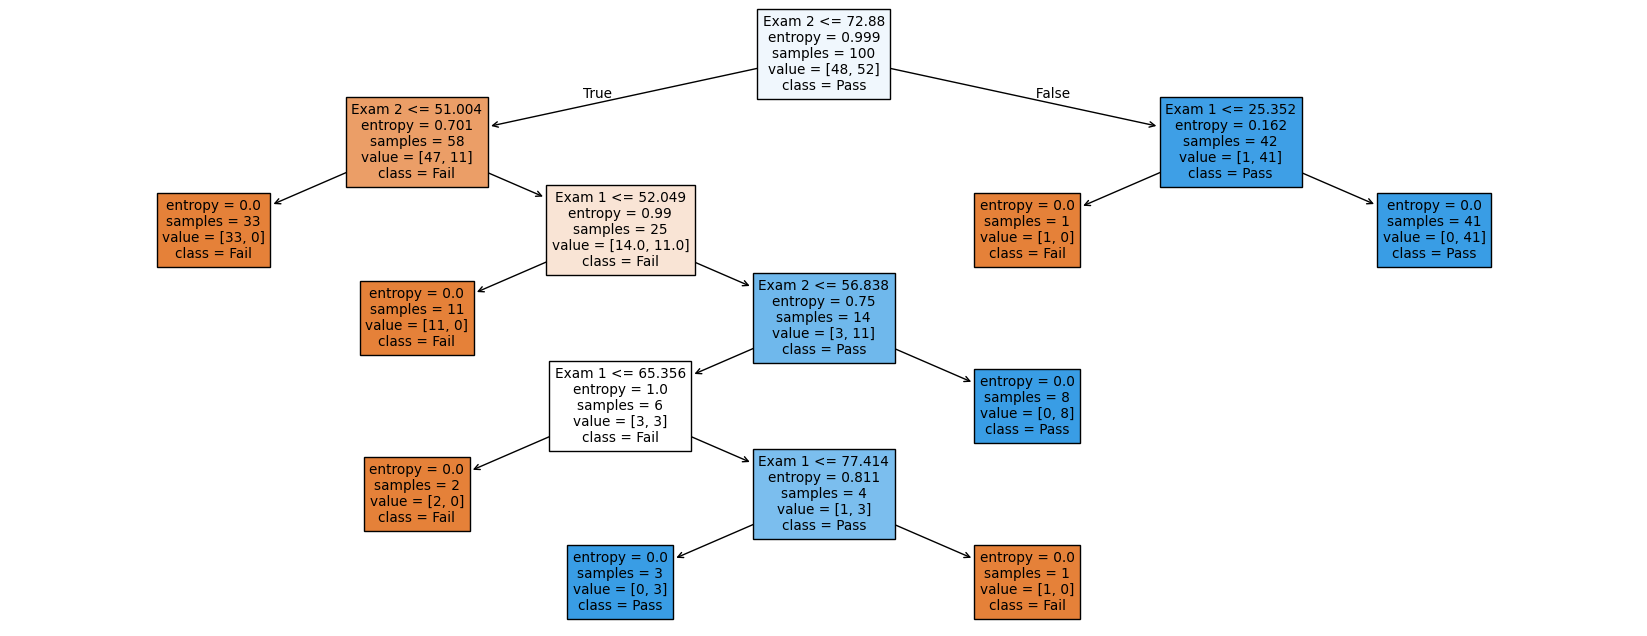

In [7]:
fig, ax = plt.subplots(figsize=(21,8))
t = tree.plot_tree(model, feature_names=['Exam 1','Exam 2'],class_names=['Fail','Pass'],label='all',filled=True)

The saved test accuracy for the synthetic pass/fail problem is **0.89**.

## 4. MNIST Dataset

MNIST contains 28×28 grayscale digit images. Each image is normalized and flattened into a 784-dimensional feature vector.

In [8]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Entropy Criterion with the Best Splitter

The first MNIST model uses entropy and the default best-split search.

In [9]:
model = DecisionTreeClassifier(criterion='entropy')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
cm = confusion_matrix(y_test, pred)
print(cm)


Accuracy 0.8846
[[ 911    1    5    3    4   19   12    5   11    9]
 [   0 1096    5    8    0    8    4    2    8    4]
 [   6    3  902   22   11   15   19   22   31    1]
 [   9    5   23  854    3   47    6   13   26   24]
 [   5    3   17    9  852    5   19   14   13   45]
 [  11    5    7   35    5  757   20    5   28   19]
 [  12    5   11    5   22   20  866    4   11    2]
 [   2   12   30   13   13    5    2  928    7   16]
 [   9    7   23   35   16   21   14    5  817   27]
 [   6    5   11   22   32   18    5   19   28  863]]


### Entropy Criterion with a Random Splitter

The same entropy criterion is retained while the splitter is changed to `random`.

In [10]:
model = DecisionTreeClassifier(criterion='entropy', splitter='random')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
cm = confusion_matrix(y_test, pred)
print(cm)

Accuracy 0.8867
[[ 930    0   10    7    1   13    8    1    6    4]
 [   0 1092    5    8    3    3    7    6   11    0]
 [  11   12  885   24   19   10   19   21   25    6]
 [   7    5   22  873    6   41    4   10   18   24]
 [   1    8    7    2  866    9   12    9   15   53]
 [  10    6   10   54   13  742   15    4   19   19]
 [  19    2   16    5   14   13  873    1   13    2]
 [   2    7   28   10   10    3    0  942    8   18]
 [  10    9   33   19   18   27   13   10  814   21]
 [   5    5    9   18   56   17    3   21   25  850]]


### Gini Criterion

The third model uses Gini impurity with the default best splitter.

In [11]:
model = DecisionTreeClassifier(criterion='gini')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
cm = confusion_matrix(y_test, pred)
print(cm)

Accuracy 0.8777
[[ 915    0    8    9    5   12   11    5   10    5]
 [   2 1093   11    4    4    4    7    2    7    1]
 [  11    9  887   31   10   11   13   22   32    6]
 [   6    6   30  855    5   46    7   11   26   18]
 [  10    4    9    5  860   12   18   10   12   42]
 [  15    7    5   45    8  754   20    7   21   10]
 [  18    6    9    3   24   23  846    2   23    4]
 [   2   13   27   17    5    4    0  926    9   25]
 [  12    9   29   41   22   31   16   10  778   26]
 [  14    4   11   15   41   11    3   21   26  863]]


## 5. Maximum-Depth Sensitivity and Overfitting

Tree depth is increased from 1 upward. Training and test accuracy are recorded at every depth, along with the number of learned leaves. The loop stops when training accuracy reaches 1.

In [12]:
train_acc = []
acc = []
max_depths = []
for m in  np.arange(1,30):
  print('max_depth =',m)
  model = DecisionTreeClassifier(criterion='entropy',max_depth=m)
  model = model.fit(x_train, y_train)

  pred = model.predict(x_train)
  accuracy = accuracy_score(y_train, pred)
  print(f'Training accuracy {accuracy:.4}')
  train_acc.append(accuracy)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Test set accuracy {accuracy:.4}')
  print('Actual leaves:',model.get_n_leaves())
  acc.append(accuracy)
  max_depths.append(m)
  if train_acc[-1]==1:
    break



max_depth = 1
Training accuracy 0.2041
Test set accuracy 0.206
Actual leaves: 2
max_depth = 2
Training accuracy 0.3367
Test set accuracy 0.3398
Actual leaves: 4
max_depth = 3
Training accuracy 0.4881
Test set accuracy 0.4918
Actual leaves: 8
max_depth = 4
Training accuracy 0.612
Test set accuracy 0.623
Actual leaves: 16
max_depth = 5
Training accuracy 0.6933
Test set accuracy 0.6995
Actual leaves: 32
max_depth = 6
Training accuracy 0.7592
Test set accuracy 0.7568
Actual leaves: 64
max_depth = 7
Training accuracy 0.8017
Test set accuracy 0.7984
Actual leaves: 128
max_depth = 8
Training accuracy 0.8465
Test set accuracy 0.8362
Actual leaves: 254
max_depth = 9
Training accuracy 0.8806
Test set accuracy 0.8615
Actual leaves: 494
max_depth = 10
Training accuracy 0.9122
Test set accuracy 0.8734
Actual leaves: 910
max_depth = 11
Training accuracy 0.9416
Test set accuracy 0.8823
Actual leaves: 1500
max_depth = 12
Training accuracy 0.9664
Test set accuracy 0.8831
Actual leaves: 2135
max_depth =

### Training and Test Accuracy vs. Maximum Depth

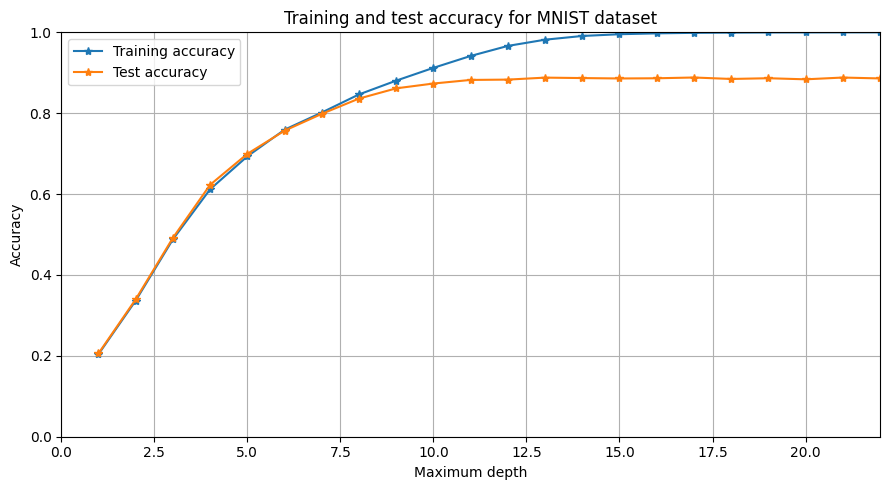

In [13]:
fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Training and test accuracy for MNIST dataset')
plt.grid(True)

ax0.plot(max_depths,train_acc, label='Training accuracy', marker='*')
ax0.plot(max_depths,acc, label='Test accuracy',  marker='*')

ax0.legend(loc='upper left')
ax0.set_xlim(0,max_depths[-1])
ax0.set_ylim(0,1)
ax0.set_xlabel('Maximum depth')
ax0.set_ylabel('Accuracy')
fig0.tight_layout()


The saved depth sweep reaches its highest test accuracy of **0.8893 at `max_depth=14`**. Beyond that point, training accuracy continues moving toward 1 while test accuracy no longer improves, illustrating overfitting.

## 6. Maximum-Leaf Sensitivity

A second complexity study controls `max_leaf_nodes`. The candidate leaf limits grow progressively until the training set is fit perfectly.

In [14]:
train_acc = []
acc = []
max_leaves = []
m = 2
while True:
  print('max_leaves =',m)
  model = DecisionTreeClassifier(criterion='entropy',max_leaf_nodes=m)
  model = model.fit(x_train, y_train)

  pred = model.predict(x_train)
  accuracy = accuracy_score(y_train, pred)
  print(f'Training accuracy {accuracy:.4}')
  train_acc.append(accuracy)
  pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print(f'Test set accuracy {accuracy:.4}')
  acc.append(accuracy)
  max_leaves.append(m)
  print('Actual leaves:',model.get_n_leaves())
  if train_acc[-1]==1:
    break
  m = m*3//2


max_leaves = 2
Training accuracy 0.2041
Test set accuracy 0.206
Actual leaves: 2
max_leaves = 3
Training accuracy 0.2772
Test set accuracy 0.2805
Actual leaves: 3
max_leaves = 4
Training accuracy 0.3367
Test set accuracy 0.3398
Actual leaves: 4
max_leaves = 6
Training accuracy 0.4213
Test set accuracy 0.429
Actual leaves: 6
max_leaves = 9
Training accuracy 0.5205
Test set accuracy 0.527
Actual leaves: 9
max_leaves = 13
Training accuracy 0.5901
Test set accuracy 0.6032
Actual leaves: 13
max_leaves = 19
Training accuracy 0.6513
Test set accuracy 0.664
Actual leaves: 19
max_leaves = 28
Training accuracy 0.6927
Test set accuracy 0.7008
Actual leaves: 28
max_leaves = 42
Training accuracy 0.7258
Test set accuracy 0.7272
Actual leaves: 42
max_leaves = 63
Training accuracy 0.7637
Test set accuracy 0.7637
Actual leaves: 63
max_leaves = 94
Training accuracy 0.7934
Test set accuracy 0.793
Actual leaves: 94
max_leaves = 141
Training accuracy 0.8207
Test set accuracy 0.8178
Actual leaves: 141
max_l

### Training and Test Accuracy vs. Number of Leaves

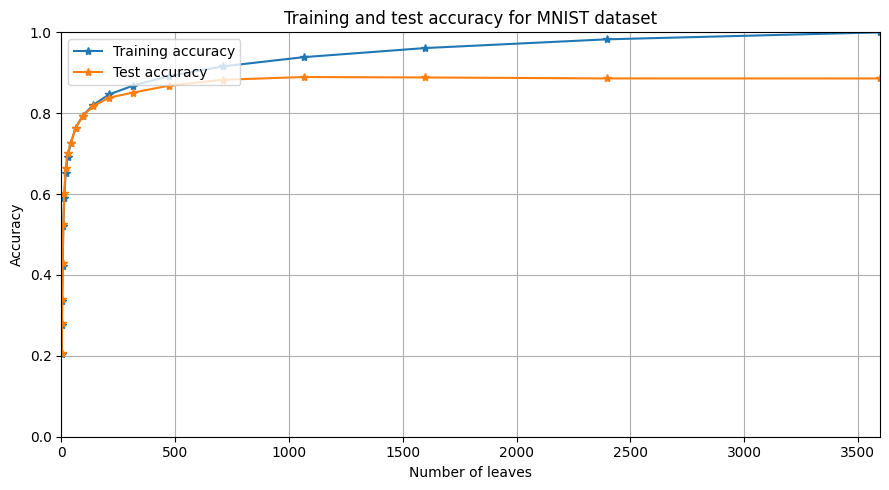

In [15]:
fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Training and test accuracy for MNIST dataset')
plt.grid(True)

ax0.plot(max_leaves,train_acc, label='Training accuracy', marker='*')
ax0.plot(max_leaves,acc, label='Test accuracy',  marker='*')

ax0.legend(loc='upper left')
ax0.set_xlim(0,max_leaves[-1])
ax0.set_ylim(0,1)
ax0.set_xlabel('Number of leaves')
ax0.set_ylabel('Accuracy')
fig0.tight_layout()

The highest saved test accuracy in the leaf sweep is **0.8889 with 1,066 leaves**. Increasing the tree size beyond that point does not improve generalization.

## 7. Comparative Results

| Dataset / Configuration | Saved Test Accuracy |
|---|---:|
| Iris — entropy | **0.9667** |
| Synthetic pass/fail — entropy | 0.8900 |
| MNIST — entropy, best splitter | 0.8870 |
| MNIST — entropy, random splitter | 0.8818 |
| MNIST — Gini, best splitter | 0.8780 |
| MNIST depth sweep — best saved point | **0.8893** |
| MNIST leaf sweep — best saved point | 0.8889 |

## 8. Key Findings

- Decision trees perform strongly on the compact Iris tabular dataset.
- The two-feature synthetic model is directly interpretable through the learned exam-score splits.
- On MNIST, entropy with the best splitter provides the strongest saved result among the three single-tree baseline configurations.
- Increasing tree depth improves training fit rapidly, but test accuracy peaks before training accuracy reaches 1.
- Limiting the number of leaves provides a second way to control tree complexity and expose the same overfitting behavior.